In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.utils.io_utils import load_csv_file, load_pickle_file
from flonacomldft.collective_variables import get_CVs
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import (
    plotting_fes_db,
    plot_losses,
    plot_sample,
    plot_correlation_target_and_predict_value
)

In [37]:
mode_labels = [0, 1]

# load datasets

zmats_train = [load_csv_file("datasets/is{:d}_md_train.csv".format(mode_label)) for mode_label in mode_labels] 
zmats_test = [load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label)) for mode_label in mode_labels]

# flow models

flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
flow_models = np.array([flow_dic['model'] for flow_dic in flows_dic])

# mlp models

mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlp_models = np.array([mlp_dic['model'] for mlp_dic in mlps_dic])


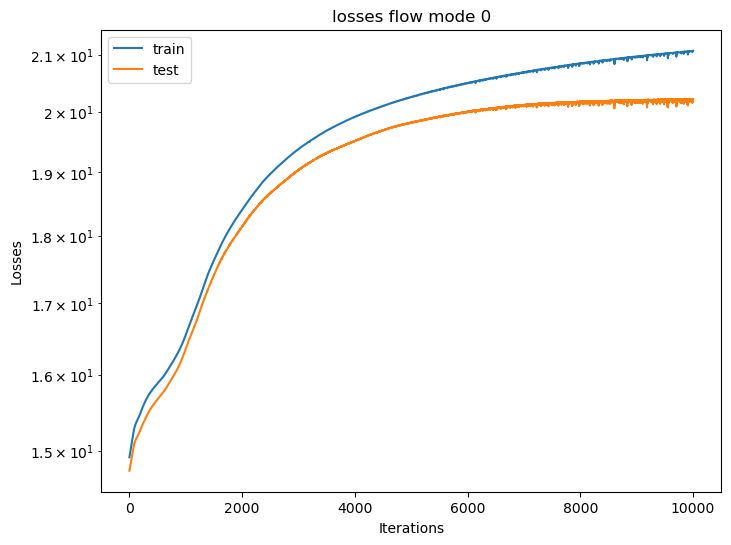

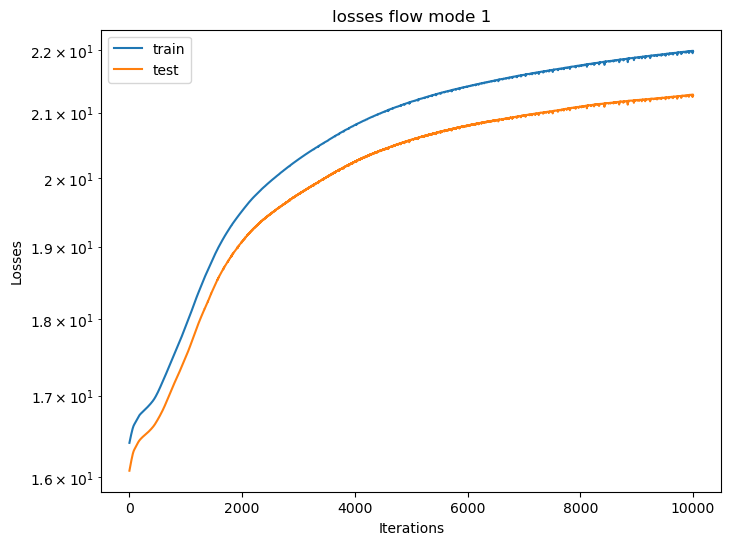

In [38]:
for mode_label in mode_labels:
    plot_losses(np.array(flows_dic[mode_label]['losses'][0])*(-1), 
            np.array(flows_dic[mode_label]['losses'][1])*(-1), title='losses flow mode {:d}'.format(mode_label), log_yscale=True)


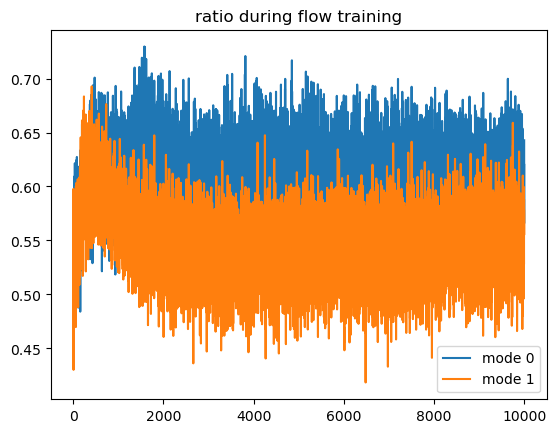

In [41]:
jump = 1
for mode_label in mode_labels:  
    plt.plot(np.arange(0, len(flows_dic[mode_label]['ratios']), jump), flows_dic[mode_label]['ratios'][::jump], label='mode {:d}'.format(mode_label))
plt.title('ratio during flow training')
plt.legend()
plt.show()

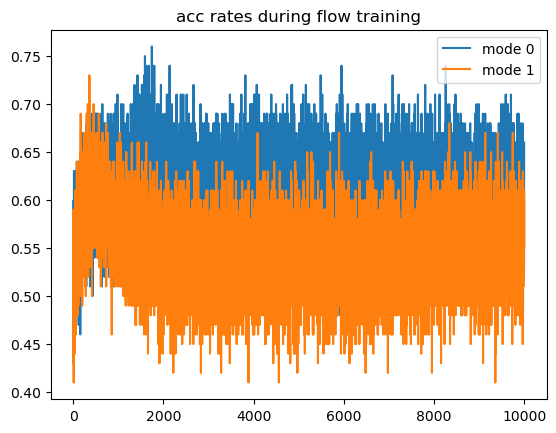

In [42]:
# TODO: fix [0], for new models training runs
for mode_label in mode_labels:  
    plt.plot(np.arange(0, len(flows_dic[mode_label]['acc_rates'][0]), jump), flows_dic[mode_label]['acc_rates'][0][::jump], label='mode {:d}'.format(mode_label))
plt.title('acc rates during flow training')
plt.legend()
plt.show()

In [6]:
coord_mapping = Coordinates_mapping()

n = 100

# md samples

x0_train_cv = np.array(get_CVs(zmats_train[0][:n, :12])).T
#x1_test_cvs = np.array(get_CVs(zmats_test[0][:n, :12])).T

x1_train_cv = np.array(get_CVs(zmats_train[1][:n, :12])).T
#x2_test_cvs = np.array(get_CVs(zmats_test[1][:n, :12]))).T

# flow samples

x0_sample = coord_mapping.get_internal_from_real_centered(flow_models[0].sample(n), isomer=0)[0]
x0_sample_cv = np.array(get_CVs(x0_sample)).T

x1_sample = coord_mapping.get_internal_from_real_centered(flow_models[1].sample(n), isomer=1)[0]
x1_sample_cv = np.array(get_CVs(x1_sample)).T



/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

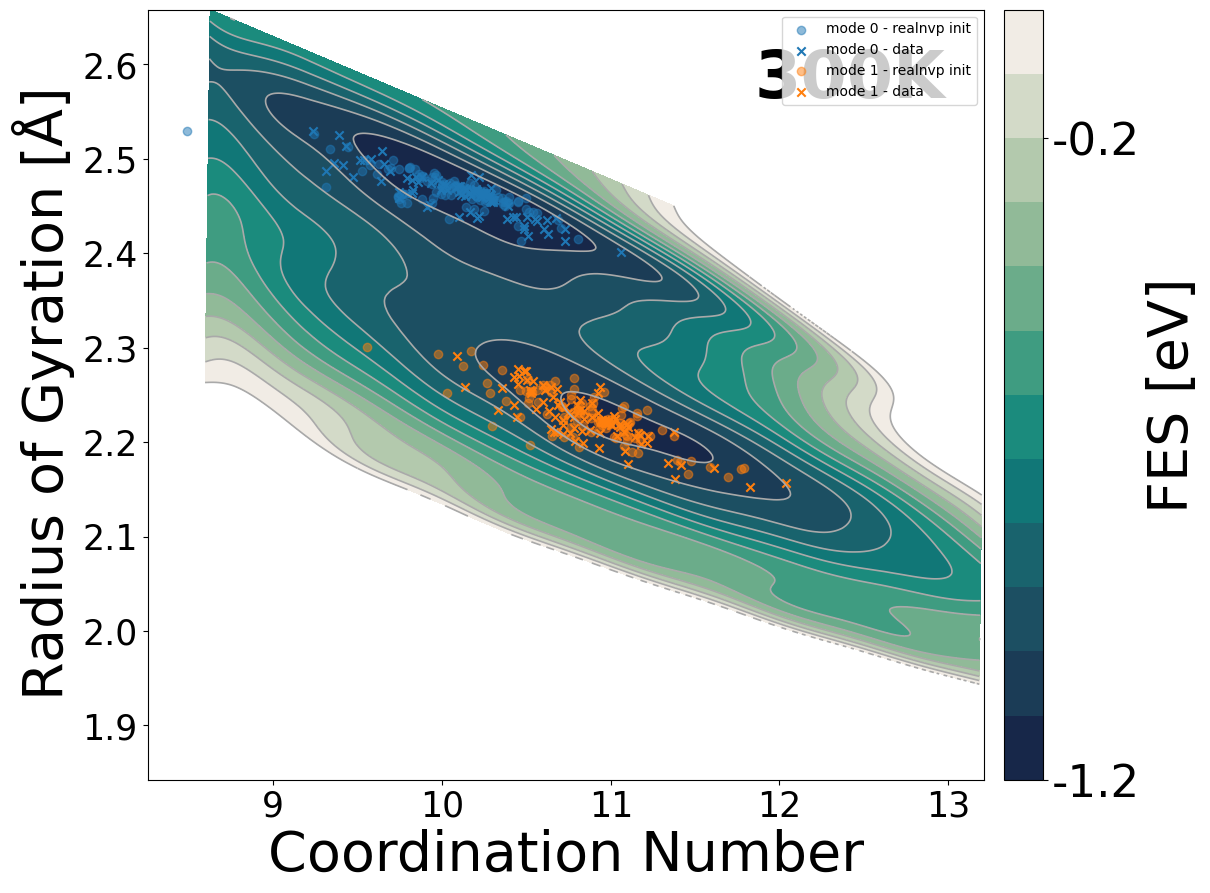

In [7]:
fig, ax = plotting_fes_db()
ax.scatter(x0_sample_cv[:, 0], x0_sample_cv[:, 1], label="mode {:d} - realnvp init".format(0), c='C{:d}'.format(0), alpha=0.5)
ax.scatter(x0_train_cv[:, 0], x0_train_cv[:, 1], marker='x', c='C{:d}'.format(0), label="mode {:d} - data".format(0))
ax.scatter(x1_sample_cv[:, 0], x1_sample_cv[:, 1], label="mode {:d} - realnvp init".format(1), c='C{:d}'.format(1), alpha=0.5)
ax.scatter(x1_train_cv[:, 0], x1_train_cv[:, 1], marker='x', c='C{:d}'.format(1), label="mode {:d} - data".format(1))
ax.legend()
plt.show()

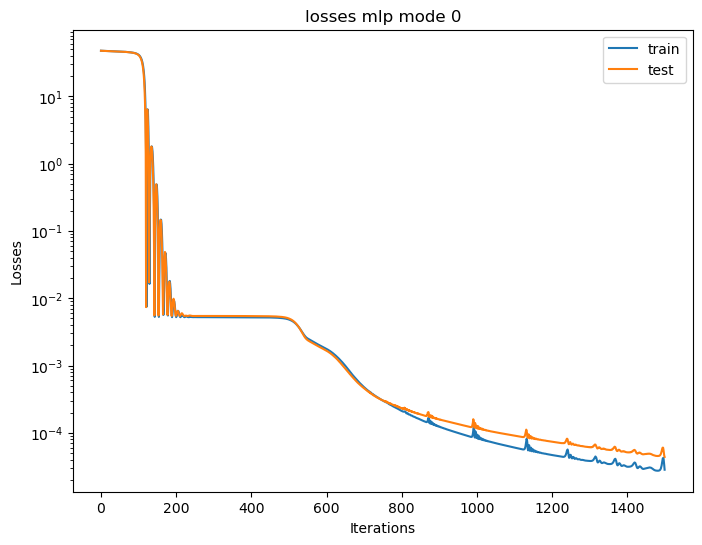

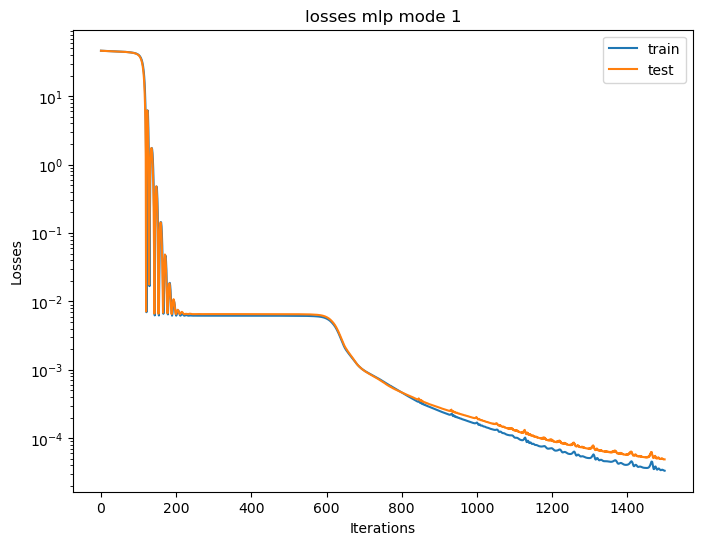

In [8]:
for mode_label in mode_labels:
    plot_losses(np.array(mlps_dic[mode_label]['losses'][0]), 
            np.array(mlps_dic[mode_label]['losses'][1]), 
            title='losses mlp mode {:d}'.format(mode_label), 
            log_yscale=True)


In [30]:
n = 1000

In [31]:
xs_train = [coord_mapping.get_real_centered_from_internal(zmat_train[:n, :12],  isomer=mode_label, energies=zmat_train[:n, 12], logdetjacs=zmat_train[:n, 14])[0] for zmat_train, mode_label in zip(zmats_train, mode_labels)]
xs_test = [coord_mapping.get_real_centered_from_internal(zmat_test[:n, :12], isomer=mode_label, energies=zmat_test[:n, 12], logdetjacs=zmat_test[:n, 14])[0] for zmat_test, mode_label in zip(zmats_test, mode_labels)]

In [32]:
pred_train = [mlp_model(xs.to(torch.float32)) for mlp_model, xs in zip(mlp_models, xs_train)]
pred_test = [mlp_model(xs.to(torch.float32)) for mlp_model, xs in zip(mlp_models, xs_test)]

In [33]:
u_train = [coord_mapping.get_real_centered_from_internal(zmat_train[:n, :12], isomer=mode_label, energies=zmat_train[:n, 12], logdetjacs=zmat_train[:n, 14])[2] for zmat_train, mode_label in zip(zmats_train, mode_labels)]
u_test = [coord_mapping.get_real_centered_from_internal(zmat_test[:n, :12], isomer=mode_label, energies=zmat_test[:n, 12], logdetjacs=zmat_test[:n, 14])[2] for zmat_test, mode_label in zip(zmats_test, mode_labels)]

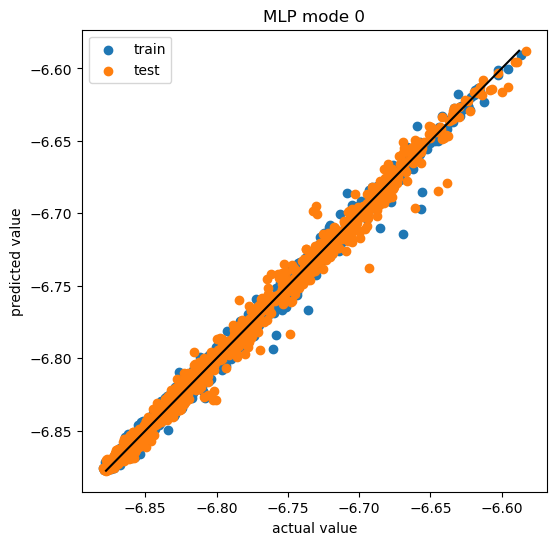

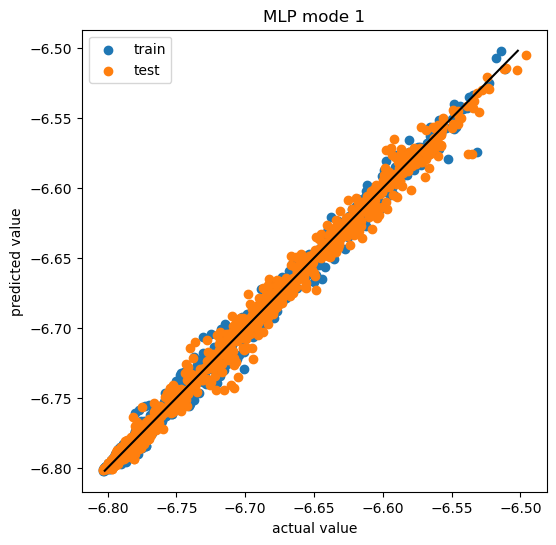

In [34]:
for u_train_, pred_train_, u_test_, pred_test_, mode_label in zip(u_train, pred_train, u_test, pred_test, mode_labels):
    plot_correlation_target_and_predict_value(
        u_train_,
        pred_train_,
        u_test_,
        pred_test_,
        title='MLP mode {:d}'.format(mode_label),
    )

In [ ]:
#==================================================================END===========================================================================#

In [36]:
from flonacomldft.utils.io_utils import get_project_path
mcmc_ex = load_pickle_file('experiments/mcmc_mixture_chains_50_steps_50.pkl', path=get_project_path())

In [ ]:
xs_mcmc = mcmc_ex['xs'].flatten(start_dim=0, end_dim=1)
isomers_mcmc = mcmc_ex['isomers'].flatten(start_dim=0, end_dim=1)

xs_mcmc_is0 = xs_mcmc[~isomers_mcmc.bool()]
xs_mcmc_is1 = xs_mcmc[isomers_mcmc.bool()]

In [ ]:
zmat_mcmc_is0, logdetjac = coord_mapping.get_internal_from_real_centered(xs_mcmc_is0, isomer=0)
zmat_mcmc_is1, logdetjac = coord_mapping.get_internal_from_real_centered(xs_mcmc_is1, isomer=1)

In [ ]:
mcmc_cv_is0 = np.array(get_CVs(zmat_mcmc_is0)).T
mcmc_cv_is1 = np.array(get_CVs(zmat_mcmc_is1)).T

In [ ]:
fig, ax = plotting_fes_db()
ax.scatter(mcmc_cv_is0[:, 0], mcmc_cv_is0[:, 1], label="mode {:d} - realnvp init".format(0), c='C{:d}'.format(0), alpha=0.5)
ax.scatter(mcmc_cv_is1[:, 0], mcmc_cv_is1[:, 1], marker='x', c='C{:d}'.format(1), label="mode {:d} - data".format(1))
ax.legend()
plt.show()

In [ ]:
from ase.visualize.plot import plot_atoms
from ase.visualize import view
plot_atoms(coord_mapping.build_molecule_from_zmat(zmat_mcmc_is0[0]))
view(coord_mapping.build_molecule_from_zmat(zmat_mcmc_is0[1057]))

In [ ]:
mcmc_cv_is0[:, 0].min()

In [ ]:
mcmc_cv_is0[mcmc_cv_is0[:, 0] == mcmc_cv_is0[:, 0].min()]

In [ ]:
torch.where(torch.tensor(mcmc_cv_is0[:, 0] == mcmc_cv_is0[:, 0].min()))